# Deep Learning Analysis of Spatial Transcriptomics Data to Identify Metabolic Vulnerabilities in Breast Cancer

## Enhanced Version with Best Practices
- Proper QC filtering
- Train/test splits
- Statistical testing
- Reproducibility controls
- Enhanced visualizations

## 1) Environment Setup & Configuration

In [1]:
# Installation (run once)
# !pip install scanpy squidpy anndata matplotlib pandas numpy scipy
# !pip install torch scvi-tools
# !pip install scikit-learn seaborn statsmodels

# =============================================================================
# CONFIGURATION PARAMETERS - Modify these for your analysis
# =============================================================================

# Random seed for reproducibility
RANDOM_SEED = 42

# QC thresholds
MIN_GENES_PER_SPOT = 200
MIN_COUNTS_PER_SPOT = 500
MAX_PCT_MITO = 20
MIN_CELLS_PER_GENE = 5

# Feature selection
N_TOP_GENES = 3000

# Deep learning parameters
LATENT_DIM = 16
DAE_EPOCHS = 60
DAE_LR = 1e-3
DAE_DROPOUT = 0.2
PREDICTOR_EPOCHS = 120
PREDICTOR_LR = 1e-3
GNN_EPOCHS = 150
GNN_LR = 1e-3

# Train/test split
TEST_SIZE = 0.2

# Statistical testing
N_PERMUTATIONS = 1000
ALPHA = 0.05

# In-silico knockdown
KNOCKDOWN_FRACTION = 0.05  # 95% reduction
TOP_K_GENES = 50

## 2) Imports & Reproducibility Setup

In [2]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import matplotlib.image as mpimg
from pathlib import Path
from scipy import sparse, stats
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.multitest import multipletests

import torch
import torch.nn as nn

# Set random seeds for reproducibility
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Scanpy settings
sc.settings.verbosity = 2
sc.set_figure_params(figsize=(6, 5), dpi=100)
warnings.filterwarnings('ignore', category=UserWarning)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Random seed: {RANDOM_SEED}")

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Using device: cpu
Random seed: 42


## 3) File Paths

In [3]:
EXPR_H5 = "Visium_Human_Breast_Cancer_filtered_feature_bc_matrix.h5"
COORDS_CSV = "Spatial-Projection.csv"
SPATIAL_DIR = "spatial"
OUTPUT_DIR = "results"

# Create output directory
Path(OUTPUT_DIR).mkdir(exist_ok=True)

## 4) Load Expression Matrix

In [4]:
adata = sc.read_10x_h5(EXPR_H5)
adata.var_names_make_unique()

# Immediately convert to sparse float32 for memory efficiency
if not sparse.isspmatrix_csr(adata.X):
    adata.X = sparse.csr_matrix(adata.X)
if adata.X.dtype != np.float32:
    adata.X = adata.X.astype(np.float32)

print(f"Loaded data: {adata.n_obs} spots × {adata.n_vars} genes")
print(f"Memory efficient: sparse={sparse.issparse(adata.X)}, dtype={adata.X.dtype}")
print(adata)

reading Visium_Human_Breast_Cancer_filtered_feature_bc_matrix.h5
 (0:00:01)
Loaded data: 4898 spots × 36601 genes
Memory efficient: sparse=True, dtype=float32
AnnData object with n_obs × n_vars = 4898 × 36601
    var: 'gene_ids', 'feature_types', 'genome'


## 5) Attach Spatial Coordinates

In [5]:
coords = pd.read_csv(COORDS_CSV)
cols = [c.strip().lower() for c in coords.columns]
coords.columns = cols

# Flexible column name handling
rename_map = {}
for c in coords.columns:
    if c in ("x coordinate", "x_coordinate", "x", "px_x"): 
        rename_map[c] = "x"
    if c in ("y coordinate", "y_coordinate", "y", "px_y"): 
        rename_map[c] = "y"
    if c in ("barcode", "barcodes"): 
        rename_map[c] = "barcode"

coords = coords.rename(columns=rename_map)
coords = coords.set_index("barcode").loc[adata.obs_names]

adata.obs["x"] = coords["x"].values
adata.obs["y"] = coords["y"].values

print("Spatial coordinates attached:")
print(adata.obs[["x", "y"]].describe())

Spatial coordinates attached:
                  x             y
count   4898.000000   4898.000000
mean   20809.838097  13757.065741
std     4954.839417   5238.900427
min    12111.000000   4650.000000
25%    16541.750000   9208.250000
50%    20822.500000  13710.000000
75%    25072.500000  18213.500000
max    29441.000000  22944.000000


## 6) Quality Control Metrics Calculation

In [6]:
# Calculate QC metrics manually to avoid densification
print("Calculating QC metrics...")

# Total counts and genes per spot
adata.obs["total_counts"] = np.ravel(adata.X.sum(axis=1))
adata.obs["n_genes_by_counts"] = np.ravel((adata.X > 0).sum(axis=1))

# Mitochondrial percentage
mt_mask = adata.var_names.str.upper().str.startswith("MT-")
n_mt_genes = mt_mask.sum()
print(f"Found {n_mt_genes} mitochondrial genes")

if mt_mask.any():
    mt_counts = np.ravel(adata[:, mt_mask].X.sum(axis=1))
    adata.obs["pct_counts_mt"] = 100.0 * (mt_counts / np.maximum(adata.obs["total_counts"], 1e-9))
else:
    adata.obs["pct_counts_mt"] = 0.0

# Gene-level QC
adata.var["n_cells_by_counts"] = np.ravel((adata.X > 0).sum(axis=0))
adata.var["total_counts"] = np.ravel(adata.X.sum(axis=0))
adata.var["mean_counts"] = adata.var["total_counts"] / adata.n_obs

print("\nQC metrics summary:")
print(adata.obs[["total_counts", "n_genes_by_counts", "pct_counts_mt"]].describe())

Calculating QC metrics...
Found 13 mitochondrial genes

QC metrics summary:
       total_counts  n_genes_by_counts  pct_counts_mt
count   4898.000000        4898.000000    4898.000000
mean   10230.296875        3522.717027       3.708904
std     6101.986328        1427.869849       2.347027
min      164.000000         140.000000       0.590711
25%     5744.000000        2470.250000       1.977259
50%     9720.500000        3654.000000       2.888844
75%    13552.000000        4509.750000       4.756965
max    54830.000000        8367.000000      14.310646


## 7) QC Visualizations

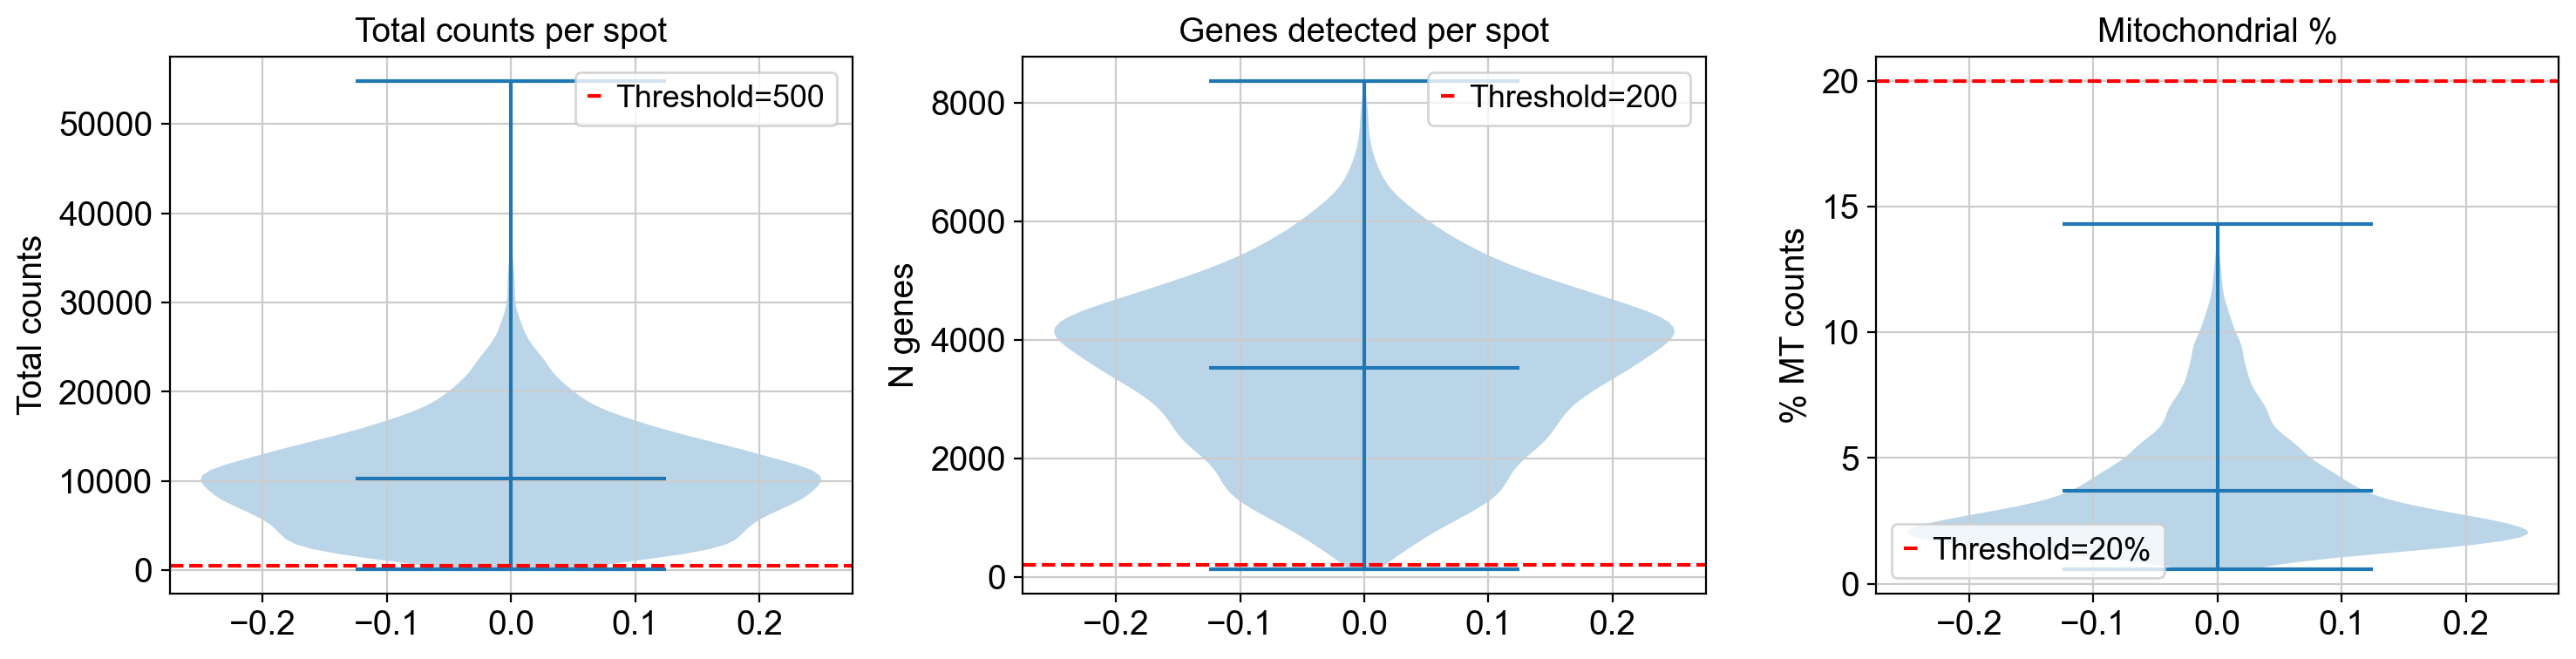

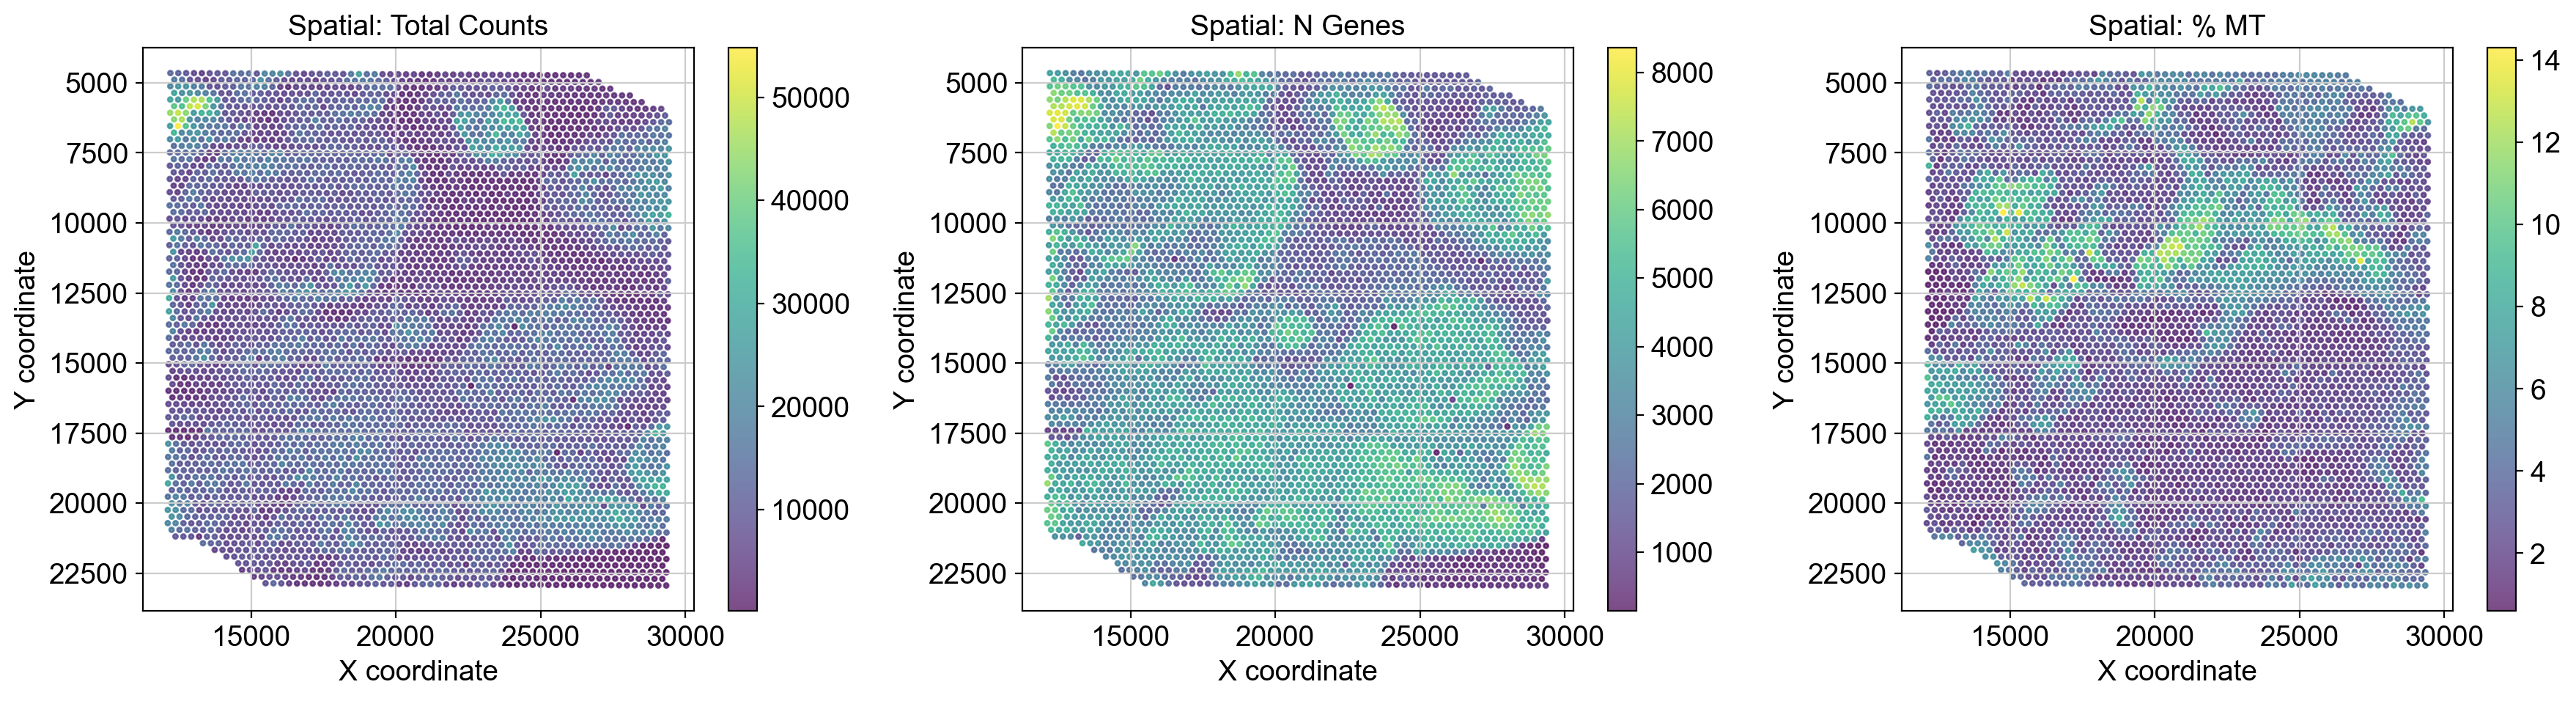

In [7]:
# QC violin plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].violinplot([adata.obs["total_counts"]], positions=[0], showmeans=True)
axes[0].set_ylabel("Total counts")
axes[0].set_title("Total counts per spot")
axes[0].axhline(MIN_COUNTS_PER_SPOT, color='r', linestyle='--', label=f'Threshold={MIN_COUNTS_PER_SPOT}')
axes[0].legend()

axes[1].violinplot([adata.obs["n_genes_by_counts"]], positions=[0], showmeans=True)
axes[1].set_ylabel("N genes")
axes[1].set_title("Genes detected per spot")
axes[1].axhline(MIN_GENES_PER_SPOT, color='r', linestyle='--', label=f'Threshold={MIN_GENES_PER_SPOT}')
axes[1].legend()

axes[2].violinplot([adata.obs["pct_counts_mt"]], positions=[0], showmeans=True)
axes[2].set_ylabel("% MT counts")
axes[2].set_title("Mitochondrial %")
if adata.obs["pct_counts_mt"].max() > 0:
    axes[2].axhline(MAX_PCT_MITO, color='r', linestyle='--', label=f'Threshold={MAX_PCT_MITO}%')
    axes[2].legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/qc_metrics.png", dpi=300, bbox_inches='tight')
plt.show()

# Spatial QC plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title in zip(axes, 
                          ["total_counts", "n_genes_by_counts", "pct_counts_mt"],
                          ["Total Counts", "N Genes", "% MT"]):
    scatter = ax.scatter(adata.obs["x"], adata.obs["y"], 
                        c=adata.obs[col], s=5, cmap='viridis', alpha=0.7)
    ax.invert_yaxis()
    ax.set_title(f"Spatial: {title}")
    ax.set_xlabel("X coordinate")
    ax.set_ylabel("Y coordinate")
    plt.colorbar(scatter, ax=ax)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/spatial_qc.png", dpi=300, bbox_inches='tight')
plt.show()

## 8) Quality Control Filtering

In [8]:
print(f"Before filtering: {adata.n_obs} spots × {adata.n_vars} genes")

# Filter spots
sc.pp.filter_cells(adata, min_genes=MIN_GENES_PER_SPOT)
print(f"After min_genes filter: {adata.n_obs} spots")

sc.pp.filter_cells(adata, min_counts=MIN_COUNTS_PER_SPOT)
print(f"After min_counts filter: {adata.n_obs} spots")

# Filter by mitochondrial percentage if applicable
if adata.obs["pct_counts_mt"].max() > 0:
    adata = adata[adata.obs["pct_counts_mt"] < MAX_PCT_MITO].copy()
    print(f"After MT% filter: {adata.n_obs} spots")

# Filter genes
sc.pp.filter_genes(adata, min_cells=MIN_CELLS_PER_GENE)
print(f"After gene filter: {adata.n_obs} spots × {adata.n_vars} genes")

print("\nFiltered QC summary:")
print(adata.obs[["total_counts", "n_genes_by_counts", "pct_counts_mt"]].describe())

Before filtering: 4898 spots × 36601 genes
filtered out 3 cells that have less than 200 genes expressed
After min_genes filter: 4895 spots
filtered out 26 cells that have less than 500 counts
After min_counts filter: 4869 spots
After MT% filter: 4869 spots
filtered out 16376 genes that are detected in less than 5 cells
After gene filter: 4869 spots × 20225 genes

Filtered QC summary:
       total_counts  n_genes_by_counts  pct_counts_mt
count   4869.000000        4869.000000    4869.000000
mean   10288.985352        3541.887862       3.708090
std     6072.406738        1410.262847       2.347369
min      506.000000         381.000000       0.590711
25%     5832.000000        2499.000000       1.977232
50%     9744.000000        3667.000000       2.881317
75%    13586.000000        4513.000000       4.758097
max    54830.000000        8367.000000      14.310646


## 9) Normalization, Log Transform, and HVG Selection

In [9]:
# 9) Normalization, Log Transform, and HVG Selection - FIXED

print(f"Current shape: {adata.n_obs} × {adata.n_vars}")

# Normalize
sc.pp.normalize_total(adata, target_sum=1e4)
print("Normalized")

Current shape: 4869 × 20225
normalizing counts per cell
    finished (0:00:00)
Normalized


In [10]:
# Log transform
sc.pp.log1p(adata)
print("Log transformed")

# MANUAL HVG selection - much more memory efficient
print("Calculating gene statistics...")

# Calculate mean and variance for each gene
gene_means = np.array(adata.X.mean(axis=0)).flatten()
gene_vars = np.array(((adata.X.power(2)).mean(axis=0) - np.power(adata.X.mean(axis=0), 2))).flatten()

# Calculate dispersion (variance/mean)
gene_disp = gene_vars / (gene_means + 1e-9)

# Select top N_TOP_GENES by dispersion
top_indices = np.argsort(gene_disp)[-N_TOP_GENES:]
adata.var['highly_variable'] = False
adata.var.iloc[top_indices, adata.var.columns.get_loc('highly_variable')] = True

print(f"Found {adata.var['highly_variable'].sum()} HVGs")

# Subset immediately
adata_hvg = adata[:, adata.var['highly_variable']].copy()
print(f"Final: {adata_hvg.n_obs} × {adata_hvg.n_vars}")

# Free memory
import gc
del gene_means, gene_vars, gene_disp, top_indices
gc.collect()

Log transformed
Calculating gene statistics...
Found 3000 HVGs
Final: 4869 × 3000


439

## 10) PCA → Neighbors → UMAP

In [ ]:
# 10) Subsample then process

print(f"Original: {adata_hvg.n_obs} spots")

# Subsample to 2000 spots for initial analysis
sc.pp.subsample(adata_hvg, n_obs=2000, random_state=RANDOM_SEED)

print(f"After subsample: {adata_hvg.n_obs} spots")

# Now PCA should work
print("Running PCA...")
sc.tl.pca(adata_hvg, n_comps=30)

print("Computing neighbors...")
sc.pp.neighbors(adata_hvg, n_neighbors=15, n_pcs=30)

print("Computing UMAP...")
sc.tl.umap(adata_hvg)

print("Done!")

Original: 4869 spots
After subsample: 2000 spots
Running PCA...
computing PCA
    with n_comps=30


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## 11) Spatial Visualization

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(adata_hvg.obs["x"], adata_hvg.obs["y"], 
           c=adata_hvg.obs["total_counts"], s=10, alpha=0.7, cmap='viridis')
plt.colorbar(label='Total counts')
plt.gca().invert_yaxis()
plt.title("Spatial Distribution (Filtered)")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.savefig(f"{OUTPUT_DIR}/spatial_overview.png", dpi=300, bbox_inches='tight')
plt.show()

## 12) Optional Tissue Image Overlay

In [ ]:
lowres_img = Path(SPATIAL_DIR) / "tissue_lowres_image.png"
sf_json = Path(SPATIAL_DIR) / "scalefactors_json.json"

if lowres_img.exists() and sf_json.exists():
    with open(sf_json) as f:
        sf = json.load(f)
    scale = sf.get("tissue_lowres_scalef", 1.0)
    xs = adata_hvg.obs["x"].values * scale
    ys = adata_hvg.obs["y"].values * scale
    img = mpimg.imread(lowres_img)
    
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.scatter(xs, ys, s=10, c=adata_hvg.obs["total_counts"], 
               alpha=0.7, cmap='viridis')
    plt.colorbar(label='Total counts')
    plt.title("Spots Overlaid on Tissue Image")
    plt.axis('off')
    plt.savefig(f"{OUTPUT_DIR}/tissue_overlay.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Image/scalefactors not found; skipping overlay.")

## 13) Metabolic Pathway Scoring

In [ ]:
# Define metabolic gene sets
metabolic_sets = {
    "Glycolysis": ["HK2", "GPI", "PFKL", "ALDOA", "TPI1", "GAPDH", 
                   "PGK1", "PGAM1", "ENO1", "PKM", "LDHA"],
    "OXPHOS": ["NDUFA1", "NDUFS1", "UQCRC1", "COX4I1", "ATP5F1A", 
               "ATP5F1B", "SDHB", "UQCRC2", "NDUFB8", "COX5A"],
    "FA_Synth": ["ACLY", "ACACA", "FASN", "SCD", "FADS2", "ELOVL6"],
    "Serine_1C": ["PHGDH", "PSAT1", "PSPH", "SHMT2", "MTHFD2"],
    "PPP": ["G6PD", "PGLS", "PGD", "TALDO1", "TKT", "RPE"],
    "Glutaminolysis": ["SLC1A5", "GLS", "GLUD1", "GPT2"]
}

# Score pathways
pathway_coverage = {}
for name, genes in metabolic_sets.items():
    present = [g for g in genes if g in adata_hvg.var_names]
    pathway_coverage[name] = len(present)
    if len(present) >= 3:
        sc.tl.score_genes(adata_hvg, present, score_name=f"{name}_score", 
                         use_raw=False)
        print(f"{name}: {len(present)}/{len(genes)} genes present")
    else:
        print(f"{name}: Only {len(present)}/{len(genes)} genes - skipping")

# Get scored pathways
met_cols = [c for c in adata_hvg.obs.columns if c.endswith("_score")]
print(f"\nScored {len(met_cols)} pathways: {met_cols}")

if met_cols:
    sc.pl.umap(adata_hvg, color=met_cols, wspace=0.4, 
              save="_metabolic_pathways.png")

## 14) Train/Test Split for Model Validation

In [ ]:
# Create train/test split
n_obs = adata_hvg.n_obs
train_idx, test_idx = train_test_split(
    range(n_obs), 
    test_size=TEST_SIZE, 
    random_state=RANDOM_SEED
)

# Add to obs
adata_hvg.obs["split"] = "test"
adata_hvg.obs.loc[adata_hvg.obs_names[train_idx], "split"] = "train"

print(f"Train set: {len(train_idx)} spots ({len(train_idx)/n_obs*100:.1f}%)")
print(f"Test set: {len(test_idx)} spots ({len(test_idx)/n_obs*100:.1f}%)")

# Visualize split
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Spatial
for split, color in [("train", "blue"), ("test", "red")]:
    mask = adata_hvg.obs["split"] == split
    axes[0].scatter(adata_hvg.obs.loc[mask, "x"], 
                   adata_hvg.obs.loc[mask, "y"],
                   s=5, alpha=0.5, label=split, c=color)
axes[0].invert_yaxis()
axes[0].legend()
axes[0].set_title("Train/Test Split (Spatial)")

# UMAP
for split, color in [("train", "blue"), ("test", "red")]:
    mask = adata_hvg.obs["split"] == split
    umap_coords = adata_hvg.obsm["X_umap"][mask]
    axes[1].scatter(umap_coords[:, 0], umap_coords[:, 1],
                   s=5, alpha=0.5, label=split, c=color)
axes[1].legend()
axes[1].set_title("Train/Test Split (UMAP)")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/train_test_split.png", dpi=300, bbox_inches='tight')
plt.show()